In [26]:
%pip install langgraph
%pip install langsmith
%pip install IPython

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<!-- #Basic components of Langgraph 
1. Edge , Nodes, State -->

# Basic Chatbot with Graph AI - LangGraph

In [3]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages



In [ ]:
class State(TypedDict):
    """State of the chatbot conversation. Messages are not replaced but added in the list of the messages."""
    messages: Annotated[list[str], add_messages] #in LangGraph is used to attach reducer functions to state fields. The reducer tells LangGraph how to merge updates from multiple nodes or graph branches.



In [ ]:

import os
import dotenv
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

model = init_chat_model(
    "gemini-2.5-flash",
    model_provider="google_genai"

)

#Node Functionality
def chatbot(state:State):
    return {"message": [model.invoke(state["messages"])]}


In [31]:
graph_builder = StateGraph(State)

graph_builder.add_node("124", chatbot)
graph_builder.add_edge(START, "124")
graph_builder.add_edge("124", END)

graph = graph_builder.compile()

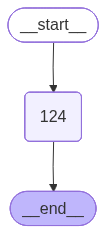

In [32]:
from IPython.display import Image, display

# Generate a PNG representation using Mermaid
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Requires optional dependencies like pygraphviz or requests for the remote API
    print("Could not render graph image. Ensure dependencies are installed.")


In [33]:
graph.invoke({"messages": ["What is the capital of France?"]})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='257a112a-772a-4fe8-a7c0-d06521146fc6')]}

In [35]:
for event in graph.stream({"messages": ["What is the capital of France?"]}):
    for value in event.values():
        print(value)

None
